# S&P 500 Options: Equal-Weight Baseline Backtest & Evaluation

**Chapter 16 - Strategy Simulation** (cost cascade: Chapter 18)

The S&P 500 straddle case study demonstrates a fundamental tension in
quantitative finance: a statistically credible signal can fail completely once
the right execution costs are applied. The strategy is a systematic
short-straddle sell on S&P 500 constituents with daily delta hedging - a
volatility-risk-premium harvest - traded on the `ret_to_expiry` label: each
cohort is entered on the final available session of each Friday week and
**held to expiry**, so the position
settles at intrinsic value and the exit leg of the round-trip bid-ask is never
paid. The backtest runs through `ml4t-backtest`'s hold-to-expiry daily-MTM
engine, which charges premium-denominated per-leg costs (entry bid-ask on both
option legs, per-contract commission, and the daily delta-hedge spread) rather
than the bps-of-notional model used for equities.

This notebook builds the **equal-weight baseline** (`stage='signal'`) of the pipeline: it sweeps the
(prediction × entry scheme) grid and characterizes the result *before* the cost
cascade is developed in full. The registry holds equal-weight baseline backtests on two
execution universes, the last two rungs of the O'Donovan-Yu (2024)
cost-mitigation cascade that Chapter 18 (`14_costs`) reads:

- **Full universe** (~600 straddles): even with hold-to-expiry removing the
  exit leg, entry-leg cost leaves the current validation surface unprofitable.
- **Liquid universe** (bottom quintile of relative half-spread, ~120 names per
  date): restricting execution to the tightest-quoted straddles helps, but does
  not make the strategy viable. The liquid-universe cross-stage rank-1 is the
  carrier; full-universe rows remain cost-comparison evidence only.

The signal strength itself is modest: accepted LSTM leads validation IC at
`+0.01384`, with an interval that includes zero. Two linear baselines have
near-zero positive Sharpe, but both still lose most of their capital. The
binding constraint is premium-denominated execution cost, not prediction
quality - the lesson the cost cascade in Section 18.8 develops from these
equal-weight baseline backtests.

**Sections:**
1. **Plumbing test** - verify the backtest engine produces no spurious alpha
2. **Parametric sweep** - sweep the (prediction × entry scheme) grid
3. **Baseline evaluation** - top strategies, family comparison, DSR, progression

Sections 1 and 2 write to `registry.db`. `SKIP_SWEEP=True` is the visible
reproduce-only control, with `ML4T_SKIP_SWEEP=1` retained for batch drivers.
A normal run materializes both execution universes before Section 3 reads them.

**Book Reference:** Chapter 16 (Sections 16.1–16.7); the cost cascade and
holdout for this case study are developed in Section 18.8

**Prerequisites:** Completed model training (Ch11–15) for this case study.

In [1]:
"""Ch16 Backtest & Signal Evaluation - S&P 500 Options case study."""

import json
import os
import sqlite3
import time
import warnings

import polars as pl

warnings.filterwarnings("ignore")

from case_studies.sp500_options.backtest_contract import (
    SP500_OPTIONS_EXECUTION_UNIVERSES,
    validate_accepted_deep_predictions,
)
from case_studies.utils.backtest_loaders import (
    get_backtest_config,
    load_backtest_prices_for,
    resolve_rebalance_timestamps,
)
from case_studies.utils.backtest_presets import (
    SP500_OPTIONS_SCHEDULE_CONTRACT,
    build_backtest_spec,
    serializable_backtest_spec,
)
from case_studies.utils.backtest_runner import (
    normalize_prediction_columns,
    run_backtest,
    run_plumbing_test,
)
from case_studies.utils.carrier_pins import carrier_pin
from case_studies.utils.cohort_reporting import cohort_metric_attribution, reportable_pbo
from case_studies.utils.registry import (
    backtest_hash_from_parts,
    load_existing_backtest_hashes,
    load_prediction_index,
    read_predictions,
)
from case_studies.utils.sweep_config import get_entry_schemes_for, get_top_n_predictions
from utils.paths import get_case_study_dir

In [2]:
CASE_STUDY_ID = "sp500_options"
LABEL = ""
SPLIT = "validation"
TOP_K = 20
MAX_SYMBOLS = 0
FORCE_REBACKTEST = False  # Set True to re-backtest even if a complete backtest_hash exists
LIQUID_QUANTILE = 0.20  # bottom quintile of relative half-spread, tightest 20%
TOP_N_PREDICTIONS = None
SKIP_SWEEP = False  # reproduce-only read of an already materialized registry
EXECUTION_UNIVERSES = list(SP500_OPTIONS_EXECUTION_UNIVERSES)

## 1. Setup & Plumbing Test

Before sweeping predictions, we verify the backtest pipeline itself is sound.
A random signal should produce Sharpe $\approx 0$. If it doesn't, the
pipeline has a bug that would contaminate all downstream results.

The S&P 500 options universe is roughly 600 delta-hedged straddles rebalanced
weekly. The plumbing test uses the generic per-leg cost printed in the term
sheet above to confirm the engine adds no spurious alpha; the sweep in
Section 2 switches to the hold-to-expiry engine, whose premium-denominated
per-leg costs are the ones that actually bind on this strategy.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
bt_config = get_backtest_config(CASE_STUDY_ID)
if TOP_N_PREDICTIONS is None:
    TOP_N_PREDICTIONS = get_top_n_predictions(CASE_STUDY_ID, "signal")

if not LABEL:
    LABEL = bt_config.primary_label

print(f"""=== Protocol Term Sheet ===
  Case study:    {CASE_STUDY_ID}
  Label:         {LABEL}
  Calendar:      {bt_config.calendar}
  Cadence:       {bt_config.cadence}
  Commission:    {bt_config.commission_bps:.1f} bps
  Slippage:      {bt_config.slippage_bps:.1f} bps
  Total cost:    {bt_config.commission_bps + bt_config.slippage_bps:.1f} bps/leg
  Long/short:    {bt_config.long_short}
""")

=== Protocol Term Sheet ===
  Case study:    sp500_options
  Label:         ret_to_expiry
  Calendar:      NYSE
  Cadence:       weekly_friday
  Commission:    5.0 bps
  Slippage:      2.0 bps
  Total cost:    7.0 bps/leg
  Long/short:    False



In [4]:
prices = load_backtest_prices_for(CASE_STUDY_ID, LABEL, split="validation", max_symbols=MAX_SYMBOLS)
n_assets = prices["symbol"].n_unique()
print(f"Prices: {len(prices):,} rows, {n_assets} assets")

Prices: 144,081 rows, 546 assets


### Liquidity Filter (Optional)

The sweep materializes both the full universe and a liquid universe restricted
each rebalance date to the bottom quintile of relative half-spread. This is the
O'Donovan-Yu (2024) execution mitigation, applied to the same model outputs.

In [5]:
_half_spread = prices.select(
    pl.col("timestamp").cast(pl.Date).alias("timestamp"),
    "symbol",
    (pl.col("instr_rel_spread") / 2).alias("half_spread"),
)
liquid_keys = (
    _half_spread.with_columns(
        (
            pl.col("half_spread").rank("min").over("timestamp")
            / pl.col("half_spread").count().over("timestamp")
        ).alias("spread_rank_pct"),
    )
    .filter(pl.col("spread_rank_pct") <= LIQUID_QUANTILE)
    .select(["timestamp", "symbol"])
)
print(
    f"Liquid subset (bottom {int(LIQUID_QUANTILE * 100)}% half-spread per date): "
    f"{len(liquid_keys):,} (symbol, date) keys"
)

Liquid subset (bottom 20% half-spread per date): 28,623 (symbol, date) keys


In [6]:
strategy_spec = build_backtest_spec(
    CASE_STUDY_ID,
    bt_config,
    prices=prices,
    prediction_hash="plumbing_test",
    initial_cash=bt_config.initial_cash,
    chapter="ch16",
    execution_mode="vectorized",
    signal={
        "method": "score_weighted_top_k",
        "top_k": TOP_K,
        "long_short": bt_config.long_short,
        "direction": "long_only",  # label ret_to_expiry already encodes short straddle return; do not double-negate
    },
)

try:
    random_sharpe = run_plumbing_test(
        CASE_STUDY_ID,
        prices,
        strategy_spec,
        top_k=TOP_K,
        initial_cash=bt_config.initial_cash,
        calendar=bt_config.calendar,
    )

    status = "PASS" if abs(random_sharpe) < 1.5 else "FAIL"
    print(f"Random signal Sharpe: {random_sharpe:.3f}  [{status}]")

    if abs(random_sharpe) >= 1.5:
        print("WARNING: Random signal produces non-trivial Sharpe - investigate pipeline")
except ValueError as e:
    if "zero variance" in str(e).lower():
        print(f"Plumbing test skipped: {e} (too few assets for meaningful test)")
        random_sharpe = 0.0
    else:
        raise

Random signal Sharpe: 0.000  [PASS]


## 2. Parametric Sweep

Sweep all (prediction × entry scheme) combinations. Every configuration uses
the same `run_backtest()` function; the sweep is pure orchestration, not a
separate code path.

Each backtest runs the hold-to-expiry engine on `ret_to_expiry`: a cohort is
entered on the final available session of its Friday week - crossing the entry
bid-ask on both option
legs and paying per-contract commission - and held to expiration, where it
settles at intrinsic value with no exit leg to cross. Open positions are marked
to the daily mid between entry and expiry, and the delta hedge is rebalanced
daily at its own spread. One run executes the full and liquid universes so a
clean registry materializes the complete comparison before downstream reads.
The versioned schedule identity is
`last_available_session_per_iso_week_v1`, which retains holiday Thursdays.

In [7]:
pred_index = load_prediction_index(
    CASE_STUDY_ID,
    label=LABEL,
    split=SPLIT,
)
if not pred_index.is_empty():
    pred_index = pred_index.filter(pl.col("family") != "causal_dml")

In [8]:
if pred_index.is_empty() and bt_config.primary_label != LABEL:
    fallback_label = bt_config.primary_label
    fallback_index = load_prediction_index(
        CASE_STUDY_ID,
        label=fallback_label,
        split=SPLIT,
    )
    if not fallback_index.is_empty():
        fallback_index = fallback_index.filter(pl.col("family") != "causal_dml")
    if not fallback_index.is_empty():
        print(
            "No predictions found for "
            f"{CASE_STUDY_ID}/{LABEL}/{SPLIT}; falling back to populated label {fallback_label}"
        )
        LABEL = fallback_label
        pred_index = fallback_index

if pred_index.is_empty():
    msg = f"No predictions found for {CASE_STUDY_ID}/{LABEL}/{SPLIT}"
    raise RuntimeError(msg)

In [9]:
pred_index = validate_accepted_deep_predictions(pred_index)
if TOP_N_PREDICTIONS > 0:
    pred_index = pred_index.head(TOP_N_PREDICTIONS)

n_predictions = len(pred_index)
print(f"Predictions to sweep: {n_predictions}")
ic_min, ic_max = pred_index["ic_mean"].min(), pred_index["ic_mean"].max()
if ic_min is not None:
    print(f"  IC range: {ic_min:.4f} - {ic_max:.4f}")
else:
    print("  IC range: not yet computed")

Predictions to sweep: 57
  IC range: -0.0163 - 0.0138


In [10]:
entry_schemes = get_entry_schemes_for(
    CASE_STUDY_ID, LABEL, n_assets, long_short=bt_config.long_short
)
n_schemes = len(entry_schemes)

print(f"\nEntry schemes ({n_schemes}):")
for es in entry_schemes:
    print(f"  {es['name']}: {es['method']} (top_k={es.get('top_k', '-')})")

invalid_universes = set(EXECUTION_UNIVERSES) - set(SP500_OPTIONS_EXECUTION_UNIVERSES)
if invalid_universes or set(EXECUTION_UNIVERSES) != set(SP500_OPTIONS_EXECUTION_UNIVERSES):
    raise ValueError(
        f"EXECUTION_UNIVERSES must contain exactly ['full', 'liquid']; got {EXECUTION_UNIVERSES!r}"
    )

total_backtests = n_predictions * n_schemes * len(EXECUTION_UNIVERSES)
print(
    f"\nTotal grid: {n_predictions} predictions × {n_schemes} schemes × "
    f"{len(EXECUTION_UNIVERSES)} universes = {total_backtests} backtests"
)


Entry schemes (3):
  ew_top5: equal_weight_top_k (top_k=5)
  ew_top10: equal_weight_top_k (top_k=10)
  ew_top20: equal_weight_top_k (top_k=20)

Total grid: 57 predictions × 3 schemes × 2 universes = 342 backtests


In [11]:
results = []
t0 = time.time()
failed = 0
failure_messages = []
skipped = 0
existing_hashes = load_existing_backtest_hashes(CASE_STUDY_ID, stage="signal")
print(f"Existing equal-weight baseline hashes in registry: {len(existing_hashes):,}")

SKIP_SWEEP = SKIP_SWEEP or os.environ.get("ML4T_SKIP_SWEEP", "").lower() in {
    "1",
    "true",
    "yes",
}

Existing equal-weight baseline hashes in registry: 342


In [12]:
def _predictions_by_universe(prediction_hash: str) -> dict[str, pl.DataFrame]:
    predictions = normalize_prediction_columns(read_predictions(CASE_STUDY_ID, prediction_hash))
    keys = liquid_keys.cast({"timestamp": predictions["timestamp"].dtype})
    return {
        "full": predictions,
        "liquid": predictions.join(keys, on=["timestamp", "symbol"], how="semi"),
    }


def _pending_specs(i: int, pred_hash: str, universe_idx: int, universe: str) -> list[tuple]:
    global skipped
    pending = []
    for j, scheme in enumerate(entry_schemes):
        idx = (i * len(EXECUTION_UNIVERSES) + universe_idx) * n_schemes + j + 1
        signal = {
            "method": scheme["method"],
            "top_k": scheme.get("top_k", 20),
            "long_short": bt_config.long_short,
            "direction": "long_only",
            "universe_filter": universe,
            **{k: v for k, v in scheme.items() if k not in ("name", "method")},
        }
        spec = build_backtest_spec(
            CASE_STUDY_ID,
            bt_config,
            prices=prices,
            prediction_hash=pred_hash,
            initial_cash=bt_config.initial_cash,
            chapter="ch16",
            execution_mode="vectorized",
            signal=signal,
        )
        bt_hash = backtest_hash_from_parts(pred_hash, serializable_backtest_spec(spec))
        if bt_hash in existing_hashes:
            skipped += 1
        else:
            pending.append((idx, scheme, spec))
    return pending

In [13]:
def _result_row(pred_row: dict, scheme: dict, universe: str, result) -> dict:
    metrics = result.metrics
    return {
        "prediction_hash": pred_row["prediction_hash"],
        "source": pred_row["source"],
        "ic_mean": pred_row["ic_mean"],
        "family": pred_row["family"],
        "config_name": pred_row["config_name"],
        "signal_method": scheme["name"],
        "universe_filter": universe,
        "backtest_hash": result.backtest_hash,
        "sharpe": metrics["sharpe"],
        "total_return": metrics["total_return"],
        "max_drawdown": metrics["max_drawdown"],
        "cagr": metrics.get("cagr", 0.0),
        "volatility": metrics.get("volatility", 0.0),
        "num_trades": metrics.get("num_trades", 0),
    }

In [14]:
def _run_pending(pred_row: dict, universe: str, predictions: pl.DataFrame, pending: list) -> None:
    global failed
    for idx, scheme, spec in pending:
        try:
            result = run_backtest(
                CASE_STUDY_ID,
                pred_row["prediction_hash"],
                spec,
                prices=prices,
                predictions=predictions,
                label=LABEL,
                register=True,
                force_rebacktest=FORCE_REBACKTEST,
                initial_cash=bt_config.initial_cash,
                calendar=bt_config.calendar,
            )
            results.append(_result_row(pred_row, scheme, universe, result))
            existing_hashes.add(result.backtest_hash)
        except Exception as error:
            failed += 1
            failure = (
                f"{pred_row['prediction_hash']}/{universe}/{scheme['name']}: "
                f"{type(error).__name__}: {error}"
            )
            failure_messages.append(failure)
            if len(failure_messages) <= 5:
                print(f"  FAILED {failure}")
        if idx % 20 == 0 or idx == total_backtests:
            elapsed = time.time() - t0
            rate = idx / elapsed if elapsed > 0 else 0
            print(
                f"  [{idx}/{total_backtests}] {elapsed:.0f}s ({rate:.1f} bt/s) | failed: {failed}"
            )

In [15]:
if SKIP_SWEEP:
    print("SKIP_SWEEP is set - reading the materialized registry; no backtests run.")
else:
    for i, pred_row in enumerate(pred_index.iter_rows(named=True)):
        prediction_hash = pred_row["prediction_hash"]
        predictions = _predictions_by_universe(prediction_hash)
        for universe_idx, universe in enumerate(EXECUTION_UNIVERSES):
            pending = _pending_specs(i, prediction_hash, universe_idx, universe)
            _run_pending(pred_row, universe, predictions[universe], pending)

SKIP_SWEEP is set - reading the materialized registry; no backtests run.


In [16]:
elapsed = time.time() - t0
if not SKIP_SWEEP:
    print(
        f"\nSweep complete: {len(results)} backtests in {elapsed:.0f}s "
        f"({failed} failed, {skipped} skipped)"
    )
    if failed:
        examples = "\n".join(failure_messages[:5])
        raise RuntimeError(
            f"Baseline sweep failed for {failed} backtests. First failures:\n{examples}"
        )

### Surface Contract

The baseline is complete only when all 342 validation configurations carry the
versioned holiday-aware weekly schedule. This fail-closed check prevents an
older literal-Friday surface from being mixed into selection.

In [17]:
with sqlite3.connect(str(CASE_DIR / "run_log" / "registry.db")) as _con:
    _surface_specs = _con.execute(
        "SELECT b.backtest_hash, b.spec_json FROM backtest_runs b "
        "JOIN prediction_sets p ON p.prediction_hash=b.prediction_hash "
        "JOIN training_runs t ON t.training_hash=p.training_hash "
        "WHERE b.stage='signal' AND p.split=? AND t.label=?",
        (SPLIT, LABEL),
    ).fetchall()

if len(_surface_specs) != total_backtests:
    raise RuntimeError(
        f"Baseline surface has {len(_surface_specs)} rows; expected {total_backtests}"
    )
_schedule_contracts = {
    json.loads(spec_json)["strategy"]["signal"].get("schedule_contract")
    for _, spec_json in _surface_specs
}
if _schedule_contracts != {SP500_OPTIONS_SCHEDULE_CONTRACT}:
    raise RuntimeError(f"Mixed or stale schedule contracts: {_schedule_contracts}")
print(f"Surface verified: {len(_surface_specs)} rows, schedule={SP500_OPTIONS_SCHEDULE_CONTRACT}")

Surface verified: 342 rows, schedule=last_available_session_per_iso_week_v1


## 2b. Single-Trade Verification

For the hold-to-expiry label, each trade's realized P&L is the short straddle
return `(entry_mid - |S_T - K|) / entry_mid`. The portfolio backtest is the
weighted sum of these trade returns per rebalance date. This section walks
through one concrete cohort by hand to prove the vectorized aggregation is
arithmetically equivalent to enumerating the per-trade P&L.

In [18]:
_cr_path = CASE_DIR / "labels" / "contract_returns.parquet"
_ret_to_expiry_path = CASE_DIR / "labels" / "ret_to_expiry.parquet"
_single_trade_inputs_exist = _cr_path.exists() and _ret_to_expiry_path.exists()


def _load_single_trade_candidates() -> pl.DataFrame:
    from data import load_sp500_daily_bars

    bars = load_sp500_daily_bars().select(
        "symbol",
        pl.col("timestamp").cast(pl.Date).alias("expiration"),
        pl.col("close").alias("S_T"),
    )
    return (
        pl.read_parquet(_cr_path)
        .join(bars, on=["symbol", "expiration"], how="inner")
        .with_columns(intrinsic=(pl.col("S_T") - pl.col("strike")).abs())
        .with_columns(
            ret_to_expiry=(pl.col("entry_straddle_mid") - pl.col("intrinsic"))
            / pl.col("entry_straddle_mid")
        )
        .select(
            "symbol",
            "feature_date",
            "entry_date",
            "expiration",
            "strike",
            "entry_straddle_mid",
            "S_T",
            "intrinsic",
            "ret_to_expiry",
        )
        .sort("feature_date", "symbol")
    )

In [19]:
if _single_trade_inputs_exist:
    _all = _load_single_trade_candidates()
else:
    _all = pl.DataFrame()
    missing = [path.name for path in (_cr_path, _ret_to_expiry_path) if not path.exists()]
    print(f"Single-trade verification skipped: missing {missing}")

if _single_trade_inputs_exist and _all.is_empty():
    print("Single-trade verification skipped: no contract-return and bar cohorts available")

In [20]:
if not _all.is_empty():
    _row = _all.row(0, named=True)
    _premium = _row["entry_straddle_mid"]
    _intrinsic = _row["intrinsic"]
    _hand_ret = (_premium - _intrinsic) / _premium
    print("Hand-computed single-trade P&L:")
    print(f"  Symbol:         {_row['symbol']}")
    print(f"  Entry date:     {_row['entry_date']} (decision close, next-session execution)")
    print(f"  Strike:         {_row['strike']}")
    print(f"  Entry premium:  {_premium:.4f}  (straddle mid at entry)")
    print(f"  Expiration:     {_row['expiration']}")
    print(f"  S_T:            {_row['S_T']:.4f}  (underlying close at expiry)")
    print(f"  Intrinsic:      {_intrinsic:.4f}  (|S_T - K|)")
    print(f"  Short return:   {_hand_ret:+.6f}  (premium minus intrinsic, divided by premium)")

Hand-computed single-trade P&L:
  Symbol:         AAL
  Entry date:     2017-01-04 (decision close, next-session execution)
  Strike:         46.5
  Entry premium:  4.2250  (straddle mid at entry)
  Expiration:     2017-02-03
  S_T:            44.2000  (underlying close at expiry)
  Intrinsic:      2.3000  (|S_T - K|)
  Short return:   +0.455621  (premium minus intrinsic, divided by premium)


In [21]:
if not _all.is_empty():
    _stored = (
        pl.read_parquet(_ret_to_expiry_path)
        .filter(
            (pl.col("symbol") == _row["symbol"]) & (pl.col("timestamp") == _row["feature_date"])
        )
        .select("ret_to_expiry")
    )
    if _stored.is_empty():
        print(
            f"No stored return for ({_row['symbol']}, {_row['feature_date']}); cross-check skipped"
        )
    else:
        _stored_val = _stored.item(0, 0)
        _diff = abs(_hand_ret - _stored_val)
        assert _diff < 1e-9, f"Single-trade mismatch: hand={_hand_ret}, stored={_stored_val}"
        print(f"Stored return: {_stored_val:+.6f}; diff: {_diff:.2e} [OK]")

Stored return: +0.455621; diff: 0.00e+00 [OK]


### Portfolio-Level Aggregation Equivalence

For any rebalance date with $K$ selected positions $s_1, \ldots, s_K$ and
weights $w_1, \ldots, w_K$ (with $\sum |w_i| = 1$ for a fully-invested
portfolio), the period P&L is:

$$\text{P\&L}_t = \sum_{i=1}^{K} w_i \cdot r^{\text{htm}}_{s_i,t}$$

Because each $r^{\text{htm}}$ is the gross trade return before implementation
costs, this sum is the pre-cost cohort P&L. The engine then subtracts the
entry option-spread and daily hedge-spread legs. Cash settlement removes the
exit option leg, but it does not remove those entry and hedge costs.

## 3. Signal Evaluation

This section is **read-only** - it queries the registry via `BacktestExplorer`
and does not depend on the sweep having just run. It can be re-run at any time.

The goal here is to characterize the equal-weight baseline result net of the
hold-to-expiry premium costs, before the full cost cascade is developed in
Chapter 18. The IC–Sharpe scatter and family comparison show how prediction
quality maps to backtest performance across both execution universes.

In [22]:
from case_studies.utils.backtest_explorer import BacktestExplorer

explorer = BacktestExplorer(CASE_STUDY_ID)
print(repr(explorer))

BacktestExplorer('sp500_options', 525 runs: allocation=150, holdout=1, htm_cost_cascade=32, signal=342)


### Top Strategies

Best equal-weight baseline backtests ranked by validation Sharpe, with the execution
`universe_filter` shown alongside. These Sharpes are net of the hold-to-expiry
premium costs described above (entry bid-ask on both legs plus the daily hedge
spread), not a mid-to-mid figure. The live output distinguishes the complete-grid
baseline leader from the pinned liquid carrier. Chapter 18 evaluates the fixed
carrier lineage across the cost cascade before the one permitted holdout use.

In [23]:
all_signal = explorer.best(stage="signal", top_n=total_backtests)
top = all_signal.head(10)
print(
    top.select(
        "backtest_hash",
        "prediction_hash",
        "source",
        "signal_method",
        "universe_filter",
        "sharpe",
        "cagr",
        "max_drawdown",
    )
)

shape: (10, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ backtest_h ┆ prediction ┆ source     ┆ signal_me ┆ universe_ ┆ sharpe    ┆ cagr      ┆ max_drawd │
│ ash        ┆ _hash      ┆ ---        ┆ thod      ┆ filter    ┆ ---       ┆ ---       ┆ own       │
│ ---        ┆ ---        ┆ str        ┆ ---       ┆ ---       ┆ f64       ┆ f64       ┆ ---       │
│ str        ┆ str        ┆            ┆ str       ┆ str       ┆           ┆           ┆ f64       │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 55bae101cd ┆ 7f7a88b203 ┆ linear/rid ┆ equal_wei ┆ full      ┆ 0.002729  ┆ -0.638926 ┆ -0.982467 │
│ bd         ┆ af         ┆ ge_a10000. ┆ ght_top_k ┆           ┆           ┆           ┆           │
│            ┆            ┆ 0          ┆           ┆           ┆           ┆           ┆           │
│ 7f32a34d10 ┆ 09af9a2b2f ┆ linear/rid ┆ equal_wei ┆ liquid    ┆ 0.001681  ┆

In [24]:
if top.is_empty():
    raise RuntimeError("No accepted baseline surface is available")
_baseline_rank1 = top.row(0, named=True)
_pin = carrier_pin(CASE_STUDY_ID)
_carrier_rows = all_signal.filter(pl.col("backtest_hash").str.starts_with(_pin or ""))
if _pin is None or len(_carrier_rows) != 1:
    raise RuntimeError(f"Carrier pin {_pin!r} resolves to {len(_carrier_rows)} baseline rows")
_carrier_row = _carrier_rows.row(0, named=True)
_carrier_dates = resolve_rebalance_timestamps(
    read_predictions(CASE_STUDY_ID, _carrier_row["prediction_hash"])["timestamp"],
    "weekly_friday",
).cast(pl.Date)
_carrier_date_strings = set(_carrier_dates.dt.to_string("%Y-%m-%d").to_list())
_holiday_thursdays = {"2019-04-18", "2020-04-09", "2020-07-02"}
if len(_carrier_dates) != 100 or not _holiday_thursdays <= _carrier_date_strings:
    raise RuntimeError(
        f"Carrier schedule is incomplete: {len(_carrier_dates)} dates, "
        f"missing={sorted(_holiday_thursdays - _carrier_date_strings)}"
    )
print(
    f"Pinned carrier {_carrier_row['backtest_hash']} uses prediction "
    f"{_carrier_row['prediction_hash']} across {len(_carrier_dates)} holiday-aware weekly sessions"
)

Pinned carrier 7f32a34d107b uses prediction 09af9a2b2fd0 across 100 holiday-aware weekly sessions


### Model Family Comparison

Accepted LSTM has the strongest validation IC on `ret_to_expiry` at `+0.01384`.
That modest, unresolved predictability does not produce an economically viable
backtest. The table below compares families by baseline Sharpe across both
execution universes. Linear contains the only two nonnegative configurations,
both near zero; every family median and every deep-learning, GBM, and TabM
configuration remains negative. Signal strength alone is insufficient once the
premium-denominated option spread is paid - the point the cost cascade in
Chapter 18 makes precise.

In [25]:
families = explorer.compare_families(stage="signal")
print(families)

shape: (4, 6)
┌───────────────┬─────┬───────────────┬────────────┬────────────┬──────────────┐
│ family        ┆ n   ┆ sharpe_median ┆ sharpe_max ┆ sharpe_q75 ┆ pct_positive │
│ ---           ┆ --- ┆ ---           ┆ ---        ┆ ---        ┆ ---          │
│ str           ┆ u32 ┆ f64           ┆ f64        ┆ f64        ┆ f64          │
╞═══════════════╪═════╪═══════════════╪════════════╪════════════╪══════════════╡
│ deep_learning ┆ 12  ┆ -0.522743     ┆ -0.261649  ┆ -0.392458  ┆ 0.0          │
│ linear        ┆ 168 ┆ -0.563802     ┆ 0.002729   ┆ -0.444318  ┆ 1.190476     │
│ gbm           ┆ 90  ┆ -0.967206     ┆ -0.574471  ┆ -0.854415  ┆ 0.0          │
│ tabular_dl    ┆ 72  ┆ -0.997844     ┆ -0.719665  ┆ -0.879464  ┆ 0.0          │
└───────────────┴─────┴───────────────┴────────────┴────────────┴──────────────┘


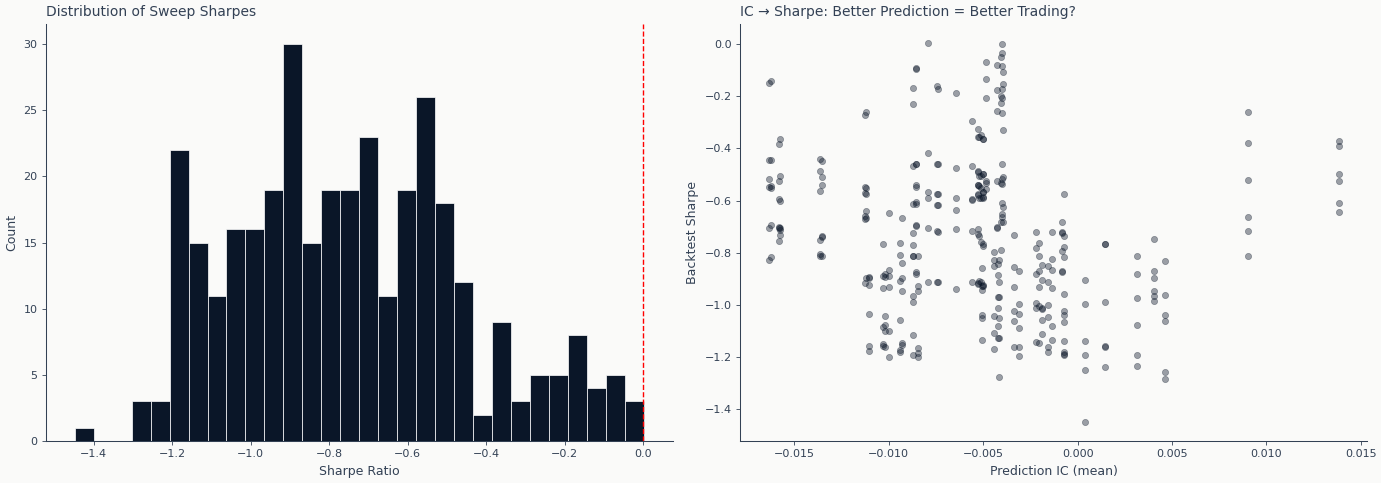

In [26]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sharpe distribution histogram
if not all_signal.is_empty():
    axes[0].hist(all_signal["sharpe"].to_numpy(), bins=30, edgecolor="white")
    axes[0].axvline(0, color="red", linestyle="--", linewidth=1)
    axes[0].set_xlabel("Sharpe Ratio")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Distribution of Sweep Sharpes")

    # IC vs Sharpe
    axes[1].scatter(
        all_signal["ic_mean"].fill_null(0).to_numpy(),
        all_signal["sharpe"].to_numpy(),
        alpha=0.4,
        s=20,
    )
    axes[1].set_xlabel("Prediction IC (mean)")
    axes[1].set_ylabel("Backtest Sharpe")
    axes[1].set_title("IC → Sharpe: Better Prediction = Better Trading?")

fig.tight_layout()
fig.show()

### Deflated Sharpe Ratio

The DSR corrects observed Sharpe ratios for the number of strategies tested.
Sweeping hundreds of (prediction × scheme) combinations inflates the best
observed Sharpe through selection. DSR estimates how much of the best strategy's
Sharpe is reproducible signal versus the lucky draw from a large candidate set.

$$DSR = \Phi\left[\frac{(\hat{SR} - SR^*) \sqrt{T-1}}{\sqrt{1 - \hat{\gamma}_3 \hat{SR} + \frac{\hat{\gamma}_4 - 1}{4} \hat{SR}^2}}\right]$$

For this case study, DSR asks whether the complete-grid baseline leader
survives the multiple-testing correction. The cohort row is attributed to
that exact leader below. If the later cross-stage carrier differs, these are
explicitly not presented as the carrier's statistics.

In [27]:
_carrier_hash = carrier_pin(CASE_STUDY_ID)
if _carrier_hash is None:
    raise RuntimeError(f"No carrier pin configured for {CASE_STUDY_ID}")
_baseline_leader_hash = _baseline_rank1["backtest_hash"]

with sqlite3.connect(str(CASE_DIR / "run_log" / "registry.db")) as _con:
    _stage_cohort_row = _con.execute(
        "SELECT leader_hash, k_variants, n_trials_effective_er, dsr_er, dsr_er_pvalue "
        "FROM cohort_metrics "
        "WHERE cohort_type='stagelabel' AND stage='signal' AND label=?",
        (LABEL,),
    ).fetchone()
    _baseline_count = _con.execute(
        "SELECT COUNT(DISTINCT b.backtest_hash) "
        "FROM backtest_runs b "
        "JOIN prediction_sets p ON p.prediction_hash=b.prediction_hash "
        "JOIN training_runs t ON t.training_hash=p.training_hash "
        "WHERE b.stage='signal' AND p.split=? AND t.label=?",
        (SPLIT, LABEL),
    ).fetchone()[0]
    _family_pbo_row = _con.execute(
        "SELECT family, leader_hash, pbo, pbo_n_combinations "
        "FROM cohort_metrics "
        "WHERE cohort_type='family' AND stage='signal' AND label=? AND leader_hash=?",
        (LABEL, _baseline_leader_hash),
    ).fetchone()

In [28]:
if _stage_cohort_row is None:
    raise RuntimeError("Missing cross-family signal/label cohort metrics")
_stage_cohort = dict(
    zip(
        ("leader_hash", "k_variants", "n_trials_effective_er", "dsr_er", "dsr_er_pvalue"),
        _stage_cohort_row,
        strict=True,
    )
)
_stage_attribution = cohort_metric_attribution(_stage_cohort, _baseline_leader_hash)
if not _stage_attribution["applies_to_carrier"]:
    raise RuntimeError(
        f"Cross-family cohort leader {_stage_cohort['leader_hash']} does not match "
        f"displayed baseline leader {_baseline_leader_hash}"
    )
if _stage_cohort["k_variants"] != _baseline_count:
    raise RuntimeError(
        f"Cohort K={_stage_cohort['k_variants']} does not match the complete "
        f"baseline grid K={_baseline_count}"
    )

In [29]:
if _family_pbo_row is None:
    raise RuntimeError("Missing carrier-family PBO metrics")
_family, _family_leader, _family_pbo, _family_pbo_n = _family_pbo_row
_family_attribution = cohort_metric_attribution(
    {"leader_hash": _family_leader}, _baseline_leader_hash
)
if not _family_attribution["applies_to_carrier"]:
    raise RuntimeError("Family PBO metrics do not match the displayed baseline leader")
_pbo_report = reportable_pbo(_family_pbo, _family_pbo_n)

print(
    f"Cross-family baseline cohort: leader={_stage_cohort['leader_hash']}, "
    f"K={_stage_cohort['k_variants']}, "
    f"K_eff(ER)={_stage_cohort['n_trials_effective_er']:.4f}"
)
print(f"Effective-rank DSR={_stage_cohort['dsr_er']:.6f}, p={_stage_cohort['dsr_er_pvalue']:.6f}")
print(f"{_family} family PBO: {_pbo_report['status']}")
if _carrier_hash != _baseline_leader_hash:
    print(f"These baseline-leader metrics do not apply to cross-stage carrier {_carrier_hash}.")

Cross-family baseline cohort: leader=55bae101cdbd, K=342, K_eff(ER)=1.9871
Effective-rank DSR=-0.009421, p=0.611476
linear family PBO: insufficient combinations (2 < 10)
These baseline-leader metrics do not apply to cross-stage carrier 7f32a34d107b.


### Sharpe Progression Preview

For the top-ranked prediction, show how Sharpe changes across the pipeline
stages already registered in the backtest explorer. The cost cascade and the
holdout evaluation are developed in Chapter 18; this is a pipeline preview, not
the final verdict on the strategy. The deployed strategy is the pinned
`ridge_a10000000.0` carrier, evaluated end-to-end in `16_strategy_analysis` and
Section 18.8.

In [30]:
if not top.is_empty():
    best_pred = _carrier_row["prediction_hash"]
    prog = explorer.progression(best_pred)
    if not prog.is_empty():
        print(f"\nSharpe progression for pinned carrier ({_carrier_row['source']}):")
        print(prog.select("stage", "sharpe", "cagr", "max_drawdown"))


Sharpe progression for pinned carrier (linear/ridge_a10000000.0):
shape: (2, 4)
┌────────────┬──────────┬───────────┬──────────────┐
│ stage      ┆ sharpe   ┆ cagr      ┆ max_drawdown │
│ ---        ┆ ---      ┆ ---       ┆ ---          │
│ str        ┆ f64      ┆ f64       ┆ f64          │
╞════════════╪══════════╪═══════════╪══════════════╡
│ signal     ┆ 0.001681 ┆ -0.788842 ┆ -0.996068    │
│ allocation ┆ 0.001681 ┆ -0.788842 ┆ -0.996068    │
└────────────┴──────────┴───────────┴──────────────┘


## Why the Cost Denominator Matters

The single most important methodological lesson of this case study is that the
*denominator* of the cost model decides the conclusion. The standard equity
model charges transaction costs as basis points of notional value. For a stock
at \$50 with a 5 bps spread that is \$0.025 per share - a rounding error against
the position. An option is different: the premium collected is a small fraction
of the underlying notional, so the same absolute bid-ask spread is a large
fraction of the *premium actually at risk*. Measured against notional the spread
looks negligible; measured against premium - the only economically meaningful
denominator for an option trade - it can consume most of the volatility-risk
premium the strategy is trying to harvest.

This is why the hold-to-expiry engine used above charges premium-denominated
per-leg costs rather than bps-of-notional, and why the two execution mitigations
matter so much. Holding to expiry removes the exit leg of the round trip
entirely: the contract settles at intrinsic value and the exit bid-ask is never
crossed. The liquid-universe filter restricts trading to the tightest-quoted
straddles. Both act on the implementation channel, not the signal - and the
baseline numbers above show why that is where the leverage is: the strongest
validation IC is LSTM's `+0.01384`, far too small to overcome a premium-denominated
spread on its own.

Chapter 18 (`14_costs`) develops the full cost cascade from these baseline
backtests - naive round-trip, hold-to-expiry, and hold-to-expiry plus the liquid
filter - and sweeps the assumed spread fraction. The cost model there charges
the strategy-favorable fraction of the quoted option half-spread that
O'Donovan-Yu (2024) adopt, so the eventual holdout survival is conditional on
that assumption; the lesson is the strategy's behavior *across* the cost grid,
not a Sharpe at any single favorable point.

## Key Takeaways

1. The plumbing test confirms no spurious alpha from the engine or
   pipeline.
2. The current carrier is the validation-only liquid-universe rank-1 after the
   allocation tie-break. The full-universe baseline leader is separate. The live
   rank table and schedule check above are authoritative for the exact hashes and
   metrics; the carrier is a lineage choice, not a viable strategy.
3. The registry-backed DSR and PBO output names the exact baseline cohort
   leader and uses all 342 baseline trials. If the cross-stage carrier differs,
   the notebook says so. Family PBO is reported as insufficient when its CSCV
   combination count cannot support a substantive estimate.
4. Two configurations have near-zero positive Sharpe, yet retain catastrophic
   drawdowns and negative CAGR. The current surface therefore preserves the
   non-viability conclusion without an all-negative claim.
5. The HTM cost dispatch (multi-cohort daily-MTM aggregation, full per-leg
   costs in % of premium) is the operative trading economics on this case
   study; Ch17 sweeps allocators and concentration on these signals, and Ch18
   reads the cost-sensitivity grid in the same premium-denominated framework.

**Next:** Ch17 sweeps allocators and concentration levels from the complete
baseline shortlist while preserving the pinned
carrier; Ch18 quantifies the cost-fraction grid in % of premium.